In [1]:
#
import tensorflow as tf
import matplotlib as plt
import numpy as np

In [2]:

!pip install -q kaggle

from google.colab import files
files.upload()   # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d eralpozcan/resistor-dataset
!unzip resistor-dataset.zip -d resistor_dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/eralpozcan/resistor-dataset
License(s): ODbL-1.0
100% 474M/474M [00:36<00:00, 13.5MB/s]

Archive:  resistor-dataset.zip
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(1).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(10).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(100).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(101).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(102).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(103).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(104).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(105).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(106).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(107).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(108).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(109).jpg  
  inflating: resistor_dataset/100R_1-4W/100R_1-4W_(11).jpg  

In [3]:
!ls /content
!ls /content/resistor_dataset

kaggle.json  resistor_dataset  resistor-dataset.zip  sample_data
100R_1-4W  150R_1-8W  20K_1-4W	 27R_1W     4700Mohm   5K61-4W	  8K2_1-4W
10_1-4W    15R_1-4W   220K_1-4W  2K2_1-4W   470R_1-4W  620R_1-4W
10R_1W	   180K_1-2W  220R_2W	 2R_1W	    470R_1W    68K_1W
10R_2W	   1K_1-4W    22R_1-4W	 330R_1-4W  4K7_1-4W   6R8_1-4W
11M_1-2W   1K_2W      24K_1-2W	 33K_2W     56K_1W     7K5_1-4W
150R_1-4W  1M_1-4W    270K_1-4W  3R9K_1-4W  5K1_1-4W   820R_1-4W


In [4]:
import os
import shutil
import random
from pathlib import Path

# path to the original dataset after unzip
original_dataset_dir = Path("/content/resistor_dataset")

# where the new split dataset will go
base_dir = Path("/content/resistor_split")

# set path for folders
train_dir = base_dir / "train"
val_dir = base_dir / "val"
test_dir = base_dir / "test"

# make split folders
for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

random.seed(42)

# loop through each resistor class folder and build path
for class_name in os.listdir(original_dataset_dir):
    class_path = original_dataset_dir / class_name

    if not class_path.is_dir():
        continue

    # mix up image order
    images = os.listdir(class_path)
    random.shuffle(images)

    # divide into 60%, 20%, 20%
    total = len(images)
    train_end = int(0.6 * total)
    val_end = int(0.8 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # create class subfolders
    (train_dir / class_name).mkdir(parents=True, exist_ok=True)
    (val_dir / class_name).mkdir(parents=True, exist_ok=True)
    (test_dir / class_name).mkdir(parents=True, exist_ok=True)

    # copy training images
    for img in train_images:
        shutil.copy(class_path / img, train_dir / class_name / img)

    # copy validation images
    for img in val_images:
        shutil.copy(class_path / img, val_dir / class_name / img)

    # copy test images
    for img in test_images:
        shutil.copy(class_path / img, test_dir / class_name / img)

print("Dataset split complete.")

Dataset split complete.


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    "/content/resistor_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = image_dataset_from_directory(
    "/content/resistor_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = image_dataset_from_directory(
    "/content/resistor_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# count the amount of class names
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 1714 files belonging to 37 classes.
Found 577 files belonging to 37 classes.
Found 590 files belonging to 37 classes.
Classes: ['100R_1-4W', '10R_1W', '10R_2W', '10_1-4W', '11M_1-2W', '150R_1-4W', '150R_1-8W', '15R_1-4W', '180K_1-2W', '1K_1-4W', '1K_2W', '1M_1-4W', '20K_1-4W', '220K_1-4W', '220R_2W', '22R_1-4W', '24K_1-2W', '270K_1-4W', '27R_1W', '2K2_1-4W', '2R_1W', '330R_1-4W', '33K_2W', '3R9K_1-4W', '4700Mohm', '470R_1-4W', '470R_1W', '4K7_1-4W', '56K_1W', '5K1_1-4W', '5K61-4W', '620R_1-4W', '68K_1W', '6R8_1-4W', '7K5_1-4W', '820R_1-4W', '8K2_1-4W']
Number of classes: 37


In [6]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds_vgg = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_vgg = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_vgg = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [7]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(num_classes, activation="softmax")
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [8]:
vgg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,669 (56.20 MB)

 Trainable params: 18,981 (74.14 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
history_vgg = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=10
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 517ms/step - accuracy: 0.0968 - loss: 4.0582 - val_accuracy: 0.2028 - val_loss: 2.9748
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 268ms/step - accuracy: 0.3308 - loss: 2.4146 - val_accuracy: 0.3206 - val_loss: 2.2809
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step - accuracy: 0.4977 - loss: 1.7711 - val_accuracy: 0.4385 - val_loss: 1.8921
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 273ms/step - accuracy: 0.6109 - loss: 1.4027 - val_accuracy: 0.4974 - val_loss: 1.6779
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 291ms/step - accuracy: 0.7025 - loss: 1.1479 - val_accuracy: 0.5529 - val_loss: 1.5120
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 294ms/step - accuracy: 0.7818 - loss: 0.9610 - val_accuracy: 0.5754 - val_loss: 1.4023
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.8069 - loss: 0.8355 - val_accuracy: 0.6049 - val_loss: 1.2925
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 307ms/step - accuracy: 0.8518 - loss: 0.7257 - val_accu

In [10]:
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_ds_vgg)
print("VGG16 Test Loss:", vgg_test_loss)
print("VGG16 Test Accuracy:", vgg_test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 700ms/step - accuracy: 0.6475 - loss: 1.1762
VGG16 Test Loss: 1.1761795282363892
VGG16 Test Accuracy: 0.6474575996398926


#Bespoke CNN

In [12]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,645 (1.91 MB)

 Trainable params: 500,645 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 434ms/step - accuracy: 0.0315 - loss: 3.5957 - val_accuracy: 0.0520 - val_loss: 3.5794
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step - accuracy: 0.0578 - loss: 3.5684 - val_accuracy: 0.0659 - val_loss: 3.5441
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.0636 - loss: 3.5885 - val_accuracy: 0.0520 - val_loss: 3.5765
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - accuracy: 0.0525 - loss: 3.5707 - val_accuracy: 0.0520 - val_loss: 3.5662
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.0525 - loss: 3.5664 - val_accuracy: 0.0520 - val_loss: 3.5766
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.0502 - loss: 3.5681 - val_accuracy: 0.0520 - val_loss: 3.5713
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step - accuracy: 0.0478 - loss: 3.5707 - val_accuracy: 0.0520 - val_loss: 3.5684
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 0.0630 - loss: 3.5006 - val_accur

In [14]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds)
print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - accuracy: 0.3237 - loss: 2.0352
CNN Test Loss: 2.035156488418579
CNN Test Accuracy: 0.3237287998199463


#Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

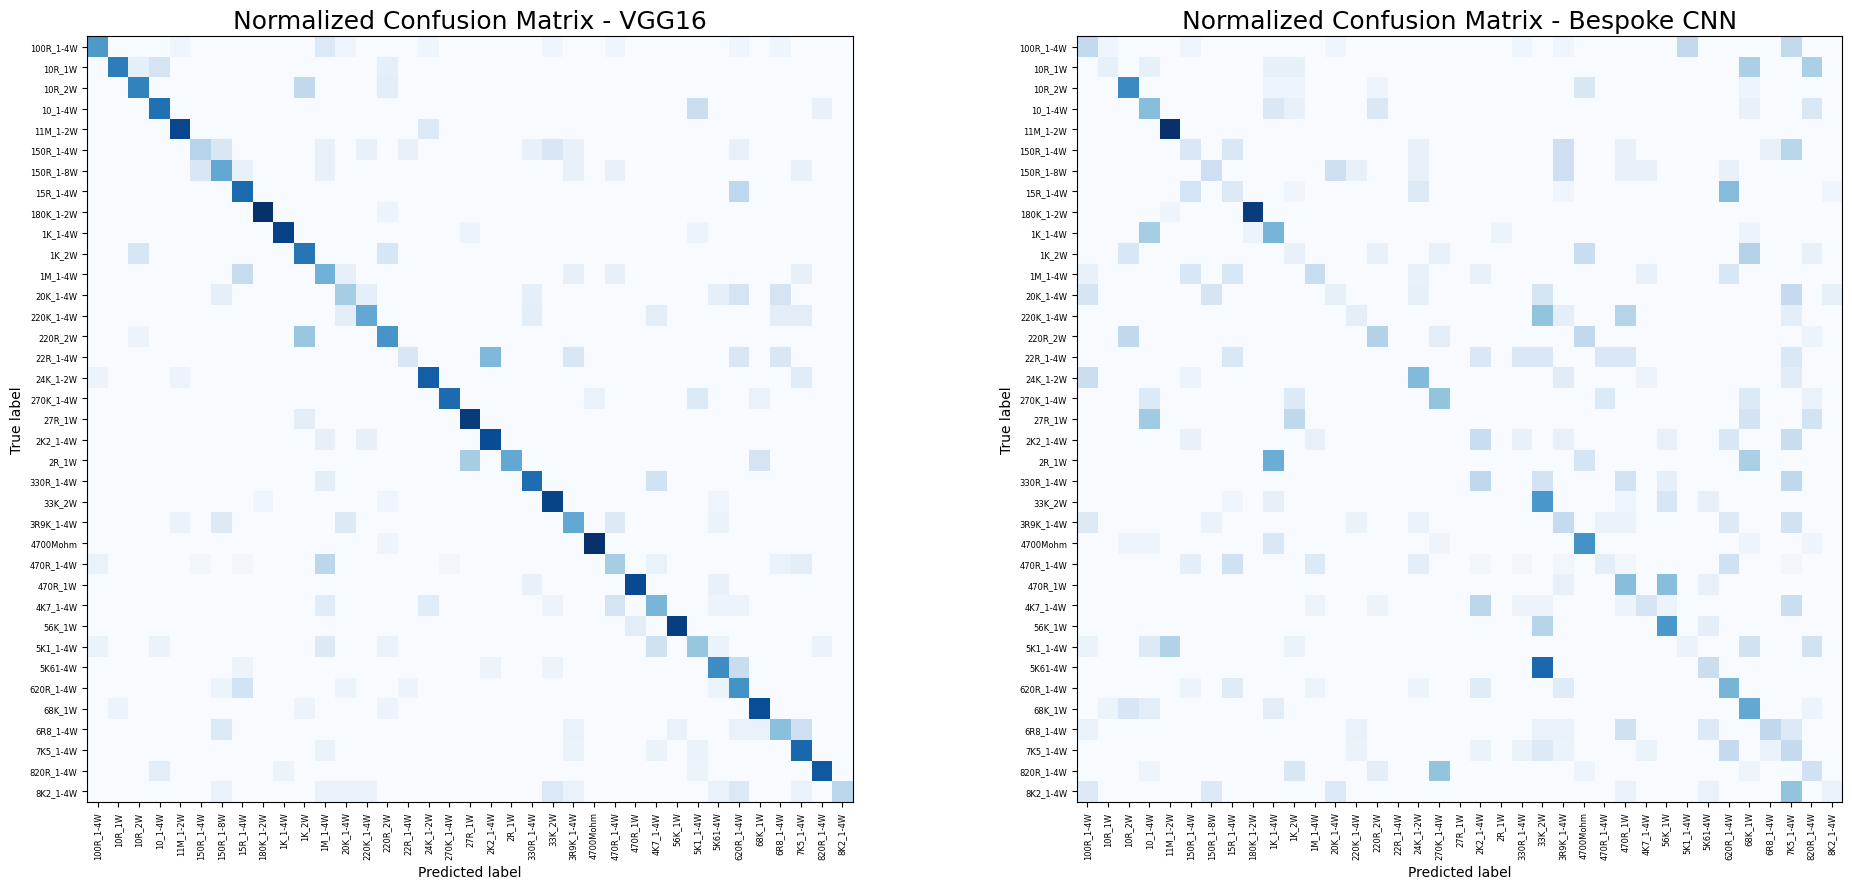

In [25]:
# Normalized confusion matrices
cm_vgg_norm = confusion_matrix(y_true, y_pred_vgg, normalize='true')
cm_cnn_norm = confusion_matrix(y_true, y_pred_cnn, normalize='true')

# Plot side by side with no cell numbers
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_vgg_norm, display_labels=class_names)
disp1.plot(ax=axes[0], cmap='Blues', xticks_rotation=90, include_values=False, colorbar=False)
axes[0].set_title("Normalized Confusion Matrix - VGG16", fontsize=18)
axes[0].tick_params(axis='x', labelsize=6)
axes[0].tick_params(axis='y', labelsize=6)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_cnn_norm, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Blues', xticks_rotation=90, include_values=False, colorbar=False)
axes[1].set_title("Normalized Confusion Matrix - Bespoke CNN", fontsize=18)
axes[1].tick_params(axis='x', labelsize=6)
axes[1].tick_params(axis='y', labelsize=6)

plt.tight_layout()
plt.show()

#Combined Line Graph

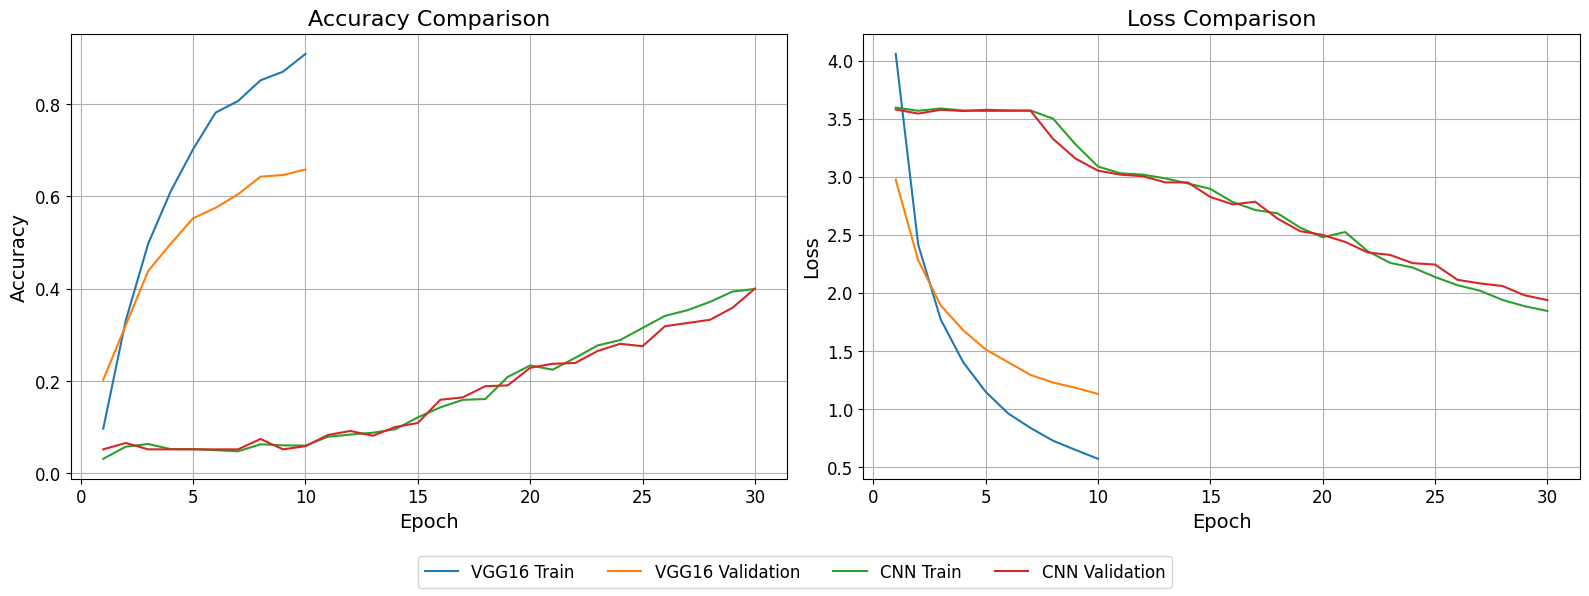

In [24]:
vgg_epochs = range(1, len(history_vgg.history['accuracy']) + 1)
cnn_epochs = range(1, len(history_cnn.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
l1, = axes[0].plot(vgg_epochs, history_vgg.history['accuracy'], label='VGG16 Train')
l2, = axes[0].plot(vgg_epochs, history_vgg.history['val_accuracy'], label='VGG16 Validation')
l3, = axes[0].plot(cnn_epochs, history_cnn.history['accuracy'], label='CNN Train')
l4, = axes[0].plot(cnn_epochs, history_cnn.history['val_accuracy'], label='CNN Validation')

axes[0].set_title('Accuracy Comparison', fontsize=16)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('Accuracy', fontsize=14)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(True)

# Loss plot
axes[1].plot(vgg_epochs, history_vgg.history['loss'])
axes[1].plot(vgg_epochs, history_vgg.history['val_loss'])
axes[1].plot(cnn_epochs, history_cnn.history['loss'])
axes[1].plot(cnn_epochs, history_cnn.history['val_loss'])

axes[1].set_title('Loss Comparison', fontsize=16)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('Loss', fontsize=14)
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(True)

fig.legend(
    [l1, l2, l3, l4],
    ['VGG16 Train', 'VGG16 Validation', 'CNN Train', 'CNN Validation'],
    loc='lower center',
    ncol=4,
    fontsize=12,
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()